### Insurance Claims Fraud Detection
#### Notebook 3 — Fraud Risk Scoring
##### Objective
Engineering a fraud risk score for each claim based on known P&C insurance fraud indicators. Each signal adds weighted points to a composite risk score, which is then categorised as 
Low / Medium / High risk.
##### Business Context
Major insurers liek BHSI, ACE in my prior decade long experience use composite risk scoring to prioritise claims for investigation. This notebook replicates that analytical approach using domain knowledge of P&C insurance fraud patterns.

#### Loading Libraries and Preprocessed Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load preprocessed claims data
claims_df = pd.read_csv('../data/processed/claims_preprocessed.csv')

print("Data loaded successfully")
print(f"Total claims: {claims_df.shape[0]:,}")
print(f"Columns: {claims_df.shape[1]}")

Data loaded successfully
Total claims: 10,000
Columns: 37


#### Quick Data Check Before calculating Fraud Score

In [3]:
# Check key fraud signal columns before scoring
fraud_columns = [
    'AUTHORITY_CONTACTED',
    'POLICE_REPORT_AVAILABLE', 
    'VENDOR_ID',
    'ANY_INJURY',
    'INCIDENT_SEVERITY',
    'CLAIM_STATUS'
]

for col in fraud_columns:
    print(claims_df[col].value_counts())
    print()  # adds blank line between columns

AUTHORITY_CONTACTED
Ambulance       4082
Police          2982
No Authority    1945
Other            991
Name: count, dtype: int64

POLICE_REPORT_AVAILABLE
1    6928
0    3072
Name: count, dtype: int64

VENDOR_ID
No Vendor    3245
VNDR00535      28
VNDR00451      28
VNDR00083      27
VNDR00167      26
             ... 
VNDR00205       9
VNDR00533       9
VNDR00240       9
VNDR00144       8
VNDR00197       6
Name: count, Length: 408, dtype: int64

ANY_INJURY
1    6991
0    3009
Name: count, dtype: int64

INCIDENT_SEVERITY
Total Loss    3390
Major Loss    3317
Minor Loss    3293
Name: count, dtype: int64

CLAIM_STATUS
A    9497
D     503
Name: count, dtype: int64



#### Building the Fraud Risk Score

In [4]:
# Initialise risk score at 0 for all claims
claims_df['RISK_SCORE'] = 0

# ── SIGNAL 1: No authority contacted (+2 points) ──────────
# In P&C insurance, genuine claims almost always involve 
# police, fire brigade or ambulance
claims_df.loc[claims_df['AUTHORITY_CONTACTED'] == 'No Authority', 
              'RISK_SCORE'] += 2

# ── SIGNAL 2: No police report available (+2 points) ──────
# Absence of police report is a classic fraud indicator
claims_df.loc[claims_df['POLICE_REPORT_AVAILABLE'] == 0, 
              'RISK_SCORE'] += 2

# ── SIGNAL 3: No vendor assigned (+2 points) ──────────────
# Claims not assigned to an investigator slip through unchecked
claims_df.loc[claims_df['VENDOR_ID'] == 'No Vendor', 
              'RISK_SCORE'] += 2

# ── SIGNAL 4: Injury involved (+1 point) ──────────────────
# Injury claims are harder to verify and have higher fraud rates
claims_df.loc[claims_df['ANY_INJURY'] == 1, 
              'RISK_SCORE'] += 1

# ── SIGNAL 5: Major or total loss severity (+2 points) ────
# Exaggerated damage is a common fraud pattern
claims_df.loc[claims_df['INCIDENT_SEVERITY'].isin(
    ['Major Loss', 'Total Loss']), 
    'RISK_SCORE'] += 2

# ── SIGNAL 6: Late night incident (+1 point) ──────────────
# Incidents between 11pm and 5am are statistically more suspicious
claims_df.loc[claims_df['INCIDENT_HOUR_OF_THE_DAY'].between(23, 5), 
              'RISK_SCORE'] += 1

# ── SIGNAL 7: High claim to premium ratio (+2 points) ─────
# Claim amount significantly higher than annual premium paid
claims_df['CLAIM_TO_PREMIUM_RATIO'] = (
    claims_df['CLAIM_AMOUNT'] / claims_df['PREMIUM_AMOUNT']
)
claims_df.loc[claims_df['CLAIM_TO_PREMIUM_RATIO'] > 3, 
              'RISK_SCORE'] += 2

# ── SIGNAL 8: New customer — low tenure (+1 point) ────────
# Fraudsters often file claims shortly after taking out a policy
claims_df.loc[claims_df['TENURE'] < 2, 
              'RISK_SCORE'] += 1

print("✅ Risk scores calculated")
print(f"\nRisk Score Distribution:")
print(claims_df['RISK_SCORE'].value_counts().sort_index())

✅ Risk scores calculated

Risk Score Distribution:
RISK_SCORE
2      372
3      807
4     1249
5     2818
6     1029
7     2436
8      325
9      859
10      34
11      71
Name: count, dtype: int64


#### Categorising Risk Level and Displaying count of claims as per the risk category

In [5]:
# Categorise each claim into Low / Medium / High risk
def categorise_risk(score):
    if score >= 7:
        return 'High Risk'
    elif score >= 4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

claims_df['RISK_CATEGORY'] = claims_df['RISK_SCORE'].apply(categorise_risk)

# Summary of risk categories
print("Risk Category Distribution:")
print(claims_df['RISK_CATEGORY'].value_counts())
print(f"\nAs percentage:")
print((claims_df['RISK_CATEGORY'].value_counts() / 
       len(claims_df) * 100).round(1))

Risk Category Distribution:
RISK_CATEGORY
Medium Risk    5096
High Risk      3725
Low Risk       1179
Name: count, dtype: int64

As percentage:
RISK_CATEGORY
Medium Risk    51.0
High Risk      37.2
Low Risk       11.8
Name: count, dtype: float64


#### Visualisation of Risk Distribution

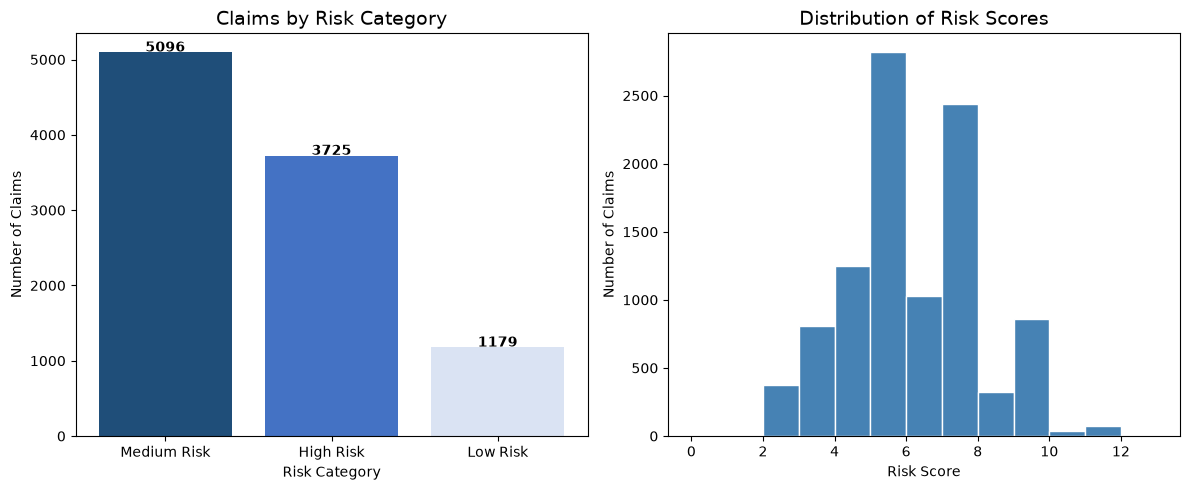

✅ Chart saved to screenshots folder


In [6]:
# Bar chart of risk categories
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 — Risk Category Count
category_counts = claims_df['RISK_CATEGORY'].value_counts()
colors = ['#1F4E79', '#4472C4', '#DAE3F3']
# Deep navy, cornflower blue, off-white blue

axes[0].bar(category_counts.index, 
            category_counts.values, 
            color=colors)
axes[0].set_title('Claims by Risk Category', fontsize=14)
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Number of Claims')

# Add value labels on bars
for i, v in enumerate(category_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Chart 2 — Risk Score Distribution
axes[1].hist(claims_df['RISK_SCORE'], 
             bins=range(0, 14), 
             color='steelblue', 
             edgecolor='white')
axes[1].set_title('Distribution of Risk Scores', fontsize=14)
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Number of Claims')

plt.tight_layout()
plt.savefig('../screenshots/risk_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to screenshots folder")

#### Key Fraud Insights

In [7]:
# Insight 1 — Average claim amount by risk category
print("Average Claim Amount by Risk Category:")
print(claims_df.groupby('RISK_CATEGORY')['CLAIM_AMOUNT'].mean().round(2))

# Insight 2 — Which signal appears most in high risk claims
high_risk = claims_df[claims_df['RISK_CATEGORY'] == 'High Risk']

print(f"\nHigh Risk Claims Analysis:")
print(f"Total high risk claims: {len(high_risk):,}")
print(f"No authority contacted: {(high_risk['AUTHORITY_CONTACTED'] == 'No Authority').sum():,}")
print(f"No police report: {(high_risk['POLICE_REPORT_AVAILABLE'] == 0).sum():,}")
print(f"No vendor assigned: {(high_risk['VENDOR_ID'] == 'No Vendor').sum():,}")

# Insight 3 — Risk by insurance type
print(f"\nRisk Category by Insurance Type:")
print(pd.crosstab(claims_df['INSURANCE_TYPE'], 
                  claims_df['RISK_CATEGORY']))

Average Claim Amount by Risk Category:
RISK_CATEGORY
High Risk      16754.77
Low Risk       16901.70
Medium Risk    16346.09
Name: CLAIM_AMOUNT, dtype: float64

High Risk Claims Analysis:
Total high risk claims: 3,725
No authority contacted: 1,368
No police report: 2,053
No vendor assigned: 2,147

Risk Category by Insurance Type:
RISK_CATEGORY   High Risk  Low Risk  Medium Risk
INSURANCE_TYPE                                  
Health                655       193          842
Life                  639       205          838
Mobile                626       191          875
Motor                 574       201          799
Property              625       182          885
Travel                606       207          857


#### Saving Final Scored Dataset

In [ ]:
# Saving the scored dataset — which will be used in Power BI
claims_df.to_csv('../data/processed/claims_fraud_scored.csv', index=False)

print("✅ Fraud scored dataset saved to data/processed/")
print(f"Final dataset: {claims_df.shape[0]:,} rows, {claims_df.shape[1]} columns")
print(f"\nNew columns added:")
print("  - CLAIM_TO_PREMIUM_RATIO")
print("  - RISK_SCORE")
print("  - RISK_CATEGORY")

✅ Fraud scored dataset saved to data/processed/
Final dataset: 10,000 rows, 40 columns

New columns added:
  - CLAIM_TO_PREMIUM_RATIO
  - RISK_SCORE
  - RISK_CATEGORY
